# ДЗ Линейная регрессия

В данном задании мы рассмотрим набор данных об учащихся, собранный в 2006 году в одной из школ Португалии. Данные представлены в неудобном для машинного обучения виде, и содержат мусор. Ваша задача &mdash; привести их к надлежащему виду и обучить на них простую модель.

Данные состоят из четырех файлов:
- data.csv &mdash; основная таблица с информацией о учащихся
- scores.csv &mdash; список финальных оценок по одному из предметов (20-балльная шкала переведенная в проценты)
- attendance.csv &mdash; таблица посещений занятий по этому предмету
- school_support.txt &mdash; список учащихся, которым оказывается финансовая поддержка

Ваша задача &mdash; построить модель для предсказания финальных оценок исходя из всех остальных данных и проверить качество ее работы с помощью кросс-валидации. В качестве алгоритма мы будем использовать линейную регрессию

Расшифровка столбцов в data.csv для справки:
- age &mdash; возраст
- Medu &mdash; уровень образования матери (по некоторой условной шкале)
- Fedu &mdash; уровень образования отца (по некоторой условной шкале)
- traveltime &mdash; время в пути до школы (1 – < 15 мин., 2 – от 15 до 30 мин., 3 – от 30 мин. to 1 ч.
или 4 – > 1 ч.)
- studytime &mdash; время, затрачиваемое на занятия вне школы (1 – < 2 ч., 2 – от 2 до 5 ч., 3 – от 5 до 10 ч. или 4 – > 10 ч.)
- famrel &mdash; насколько хорошие отношения в семье у учащегося (по некоторой условной шкале)
- freetime &mdash; количество свободного времени вне школы (по некоторой условной шкале)
- goout &mdash; время, затрачиваемое на общение с друзьями (по некоторой условной шкале)
- Dalc &mdash; количество употребления алкоголя в учебные дни (по некоторой условной шкале)
- Walc &mdash; количество употребления алкоголя в неучебные дни (по некоторой условной шкале)
- health &mdash; уровень здоровья (по некоторой условной шкале)
- sex_M &mdash; пол: мужской (1) или женский (0)
- address_U &mdash; живет ли учащийся в городе (1) или в пригороде (0)
- famsize_LE3 &mdash; размер семьи: не больше 3 человек (1) или больше (0)
- Pstatus_T &mdash; живут ли родители вместе (1) или отдельно (0)
- nursery &mdash; посещал ли учащийся детский сад
- plans_university &mdash; планирует ли учащийся поступать в университет (-1 или 1)
- past_failures &mdash; количество неудовлетворительных оценок по другим предметам ранее (от 0 до 4)

*Примечание. Несколько признаков в данных содержат ошибки/проблемы/некорректности. Эти проблемы нужно исправить. Для
проверки &mdash; всего в данных таких проблем четыре.*

Начиная с 4 пункта делайте кроссвалидацию на 4 батча до и после, замеряйте результат

### Задача 1: сломанный признак (а может и не один)
__(1 балл)__

Загрузите таблицу data.csv.

Найдите в данных сломанный признак (он не соответствует описанию) и исправьте его.

In [2]:
#год рожд вместо возраста
#traveltime в минутах указан
#слиплись plans_universitypast_failures  

import pandas as pd
import numpy as np

data = pd.read_csv("data.csv")

#print("col", data.columns.tolist())
#print(data.head())
#print(data.describe())

mask_y = data["age"] > 100
data.loc[mask_y, "age"] = 2006 - data.loc[mask_y, "age"]

def cor_t(x):
    if x <= 4: return x
    if x <= 15: return 1
    if x <= 30: return 2
    if x <= 60: return 3
#elif
    return 4;

def plans_university(x):
    if x < 0: return -1
    return 1

def past_failures(x):
    return abs(x) % 10


data["traveltime"] = data["traveltime"].apply(cor_t)

last = data.columns[-1]

data["plans_university"] = data[last].apply(plans_university)
data["past_failures"] = data[last].apply(past_failures)

data = data.drop(columns=[last])

print(data["age"].describe())              # min 15, max 22
print(data["traveltime"].value_counts())   # только 1, 2, 3, 4
print(data["plans_university"].unique())   # [-1, 1]
print(data["past_failures"].unique())      # 0..4, без 9
print(data.shape) 


count    649.000000
mean      16.744222
std        1.218138
min       15.000000
25%       16.000000
50%       17.000000
75%       18.000000
max       22.000000
Name: age, dtype: float64
traveltime
1    366
2    213
3     54
4     16
Name: count, dtype: int64
[ 1 -1]
[0 1 3 2]
(649, 18)


### Задача 2: пропуски в данных 
__(1 балл)__

Проверьте, есть ли в данных пропуски (значения NaN). Замените все пропущенные значения на среднее значение этого признака по столбцу.

*Hint: изучите в pandas функции loc, isnull, а также передачу булевых массивов в качестве индексов.*

In [3]:
#data = data.fillna(data.mean)

data = data.astype(float)

for col in data.columns:
    mask = data[col].isnull()
    data.loc[mask, col] = data[col].mean()

### Задача 3: нормализация данных
__(1 балл)__

Нормализуйте данные любым способом, в современных библиотеках нормализация часто встроена внутрь модели, поэтому тут разницы может и не быть в качестве, но сделать надо

In [4]:
data = (data - data.min()) / (data.max() - data.min())

### Задача 4: кросс-валидация для исходных данных
__(1 балл)__

Загрузите файл scores.csv и протестируйте, как линейная регрессия предсказывает ответ сейчас (с помощью кросс-валидации).

Кроссвалидацию сделайте по 4 разбивкам. Выведите качество в каждом их разбиений.

*Hint: воспользуйтесь sklearn.linear_model и sklearn.model_selection.*

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

scores = pd.read_csv("scores.csv", header=None).values.ravel()
# - np - выпрямить 

model = LinearRegression()
mse = -cross_val_score(model, data, scores, cv=4, scoring="neg_mean_squared_error")

print(mse)
print(mse.mean())

[164.80709124 244.39732999 242.73621019 233.96708369]
221.47692877811048


### Задача 5: полные данные
__(2 балла)__

Воспользуйтесь файлами attendance.csv и school_support.txt для того, чтобы добавить новые признаки в данные. Желательно по максимуму использовать возможности pandas для упрощения преобразований.

school_suport число в строке значит что i-ый школьник из исходной таблицы получал мат помощь (обратите внимание что строк в файле меньше, подумайте как правильно импортировать данные)

Добавьте данные таким образом, чтобы качество выросло

In [16]:
with open("school_support.txt") as f:
    nums = [int(line) for line in f]

data["school_support"] = 0

for n in nums:
    data.loc[n, "school_support"] = 1

att = pd.read_csv("attendance.csv", sep=";")

att_plus = (att == "+").astype(int) 
visits = att_plus.sum(axis=1)  
total = att.shape[1]

data["attendance_rate"] = visits / total

model = LinearRegression()
mse = -cross_val_score(model, data, scores, cv=4, scoring="neg_mean_squared_error")

print(mse)
print(mse.mean())

[159.48080432 237.70952975 246.68717342 233.40122005]
219.31968188660977


### Задача 6: борьба с выбросами
__(1.5 балла)__

Качество предсказания может ухудшаться, если в данных присутствуют корректные значения признаков (с точки зрения чтения данных и применения методов), но не соответствующие реальным объектам. Например, данные могли быть введены в неверном формате, а потом слишком грубо приведены к общему виду, из-за чего ошибка не была замечена.
Попробуем от такого избавиться &mdash; а для этого такие объекты нужно сначала найти. Конечно, нам еще недоступны многие продвинутые способы, но давайте попробуем обойтись простыми.

Первый способ это сделать &mdash; посмотреть для каждого признака на распределение его значений и проверить крайние значения на правдоподобность. (постройте гистограммы для признаков, как минимум для подозрительных)

*Hint 1: используйте функцию DataFrame.hist*

*Hint 2: в описании датасета выше есть информация, необходимая для восстановления правильных значений*

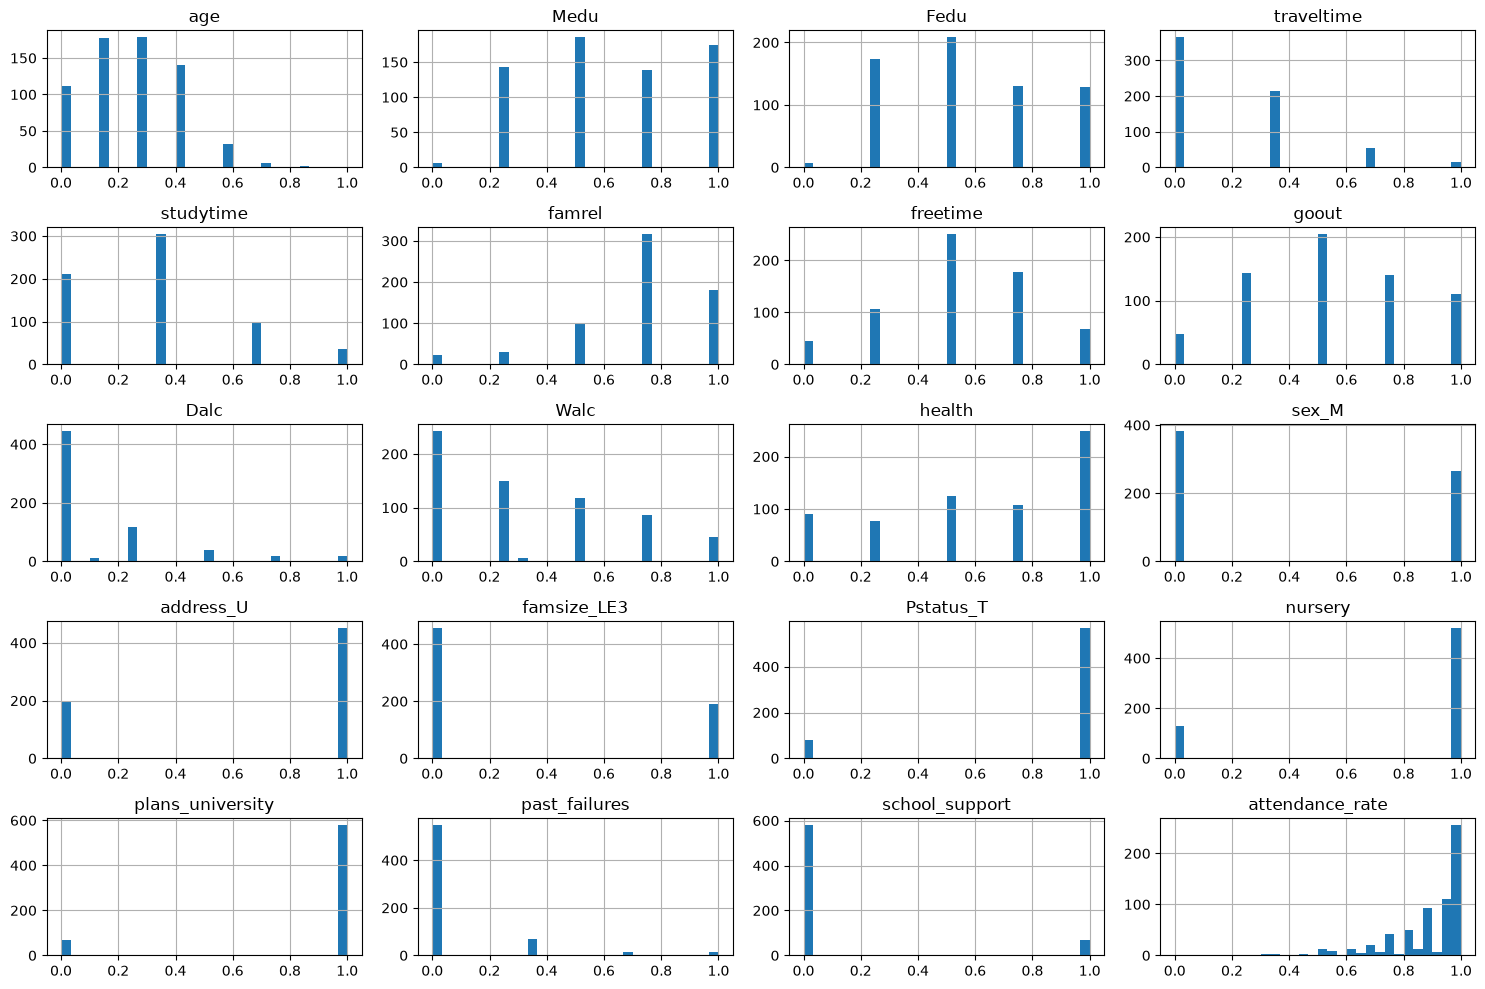

In [19]:
import matplotlib.pyplot as plt

data.hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

__(1.5 балла)__

Другой простой способ найти выбросы &mdash; сделать предсказание и посчитать ошибку на каждом объекте по отдельности и посмотреть на объекты с наибольшей ошибкой. Обучите линейную регрессию (функция fit) и для каждого объекта посчитайте среднеквадратичное отклонение. Постройте гистограмму распределения ошибок. Посмотрите на гистограмму и удалите из выборки те объекты на которых ошибка слишком большая.

Обратите внимание, что просто удалять все объекты с высокой ошибкой нельзя &mdash; это, конечно, хороший способ добиться меньшей ошибки (на данной выборке), но одновременно вы ухудшите обобщающую способность алгоритма. Вместо этого вам нужно найти однозначно ошибочные записи и их исправить.

*Hint: возможно, все проблемы уже были найдены первым способом; для проверки &mdash; в сумме здесь нужно исправить 3 проблемы.*

Для поиска ошибки на одном отдельном обьекте придётся обучить линейную регрессию руками. Частичный пример, допишите код. Постройте гистограмму распределения ошибок

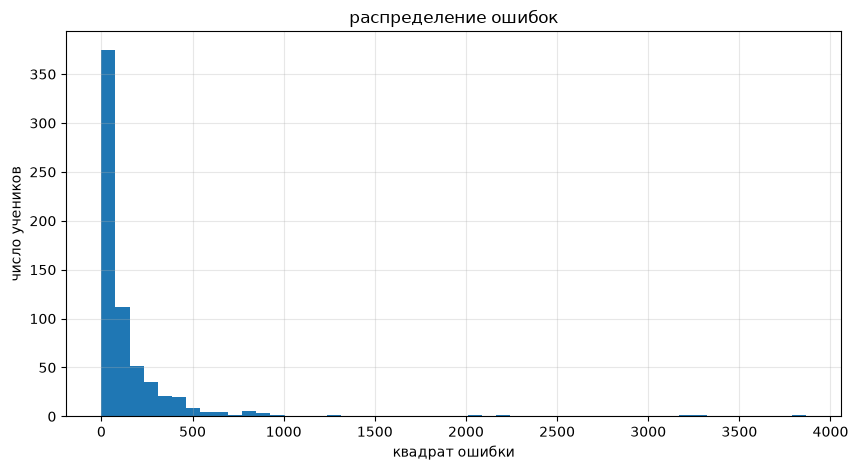

[165 438 262 188 196 231 436 404 257 585]

[ 854.22345587  895.73255953  902.43834257  964.00299366 1278.71009262
 2050.02722813 2173.28461464 3244.80250074 3254.25110865 3865.26071489]
=== age ===
count    649.000000
mean       0.248943
std        0.173118
min        0.000000
25%        0.142857
50%        0.285714
75%        0.428571
max        0.857143
Name: age, dtype: float64

> 0.9
Empty DataFrame
Columns: [age, Medu, Fedu, traveltime, studytime, famrel, freetime, goout, Dalc, Walc, health, sex_M, address_U, famsize_LE3, Pstatus_T, nursery, plans_university, past_failures, school_support, attendance_rate]
Index: []

Топ-10 ошибок
          age  Medu  Fedu  traveltime  studytime  famrel  freetime  goout  \
423  0.142857  0.25  0.25    0.333333   0.333333    1.00      0.75   1.00   
404  0.285714  1.00  0.75    0.333333   0.333333    0.75      1.00   1.00   
462  0.428571  0.50  0.50    0.666667   0.333333    0.75      0.50   0.50   
257  0.000000  0.75  0.50    0.000000   0.333333

In [34]:
import numpy as np

model = LinearRegression()
model.fit(data, scores)

predictions = model.predict(data)
errors = (predictions - scores) ** 2

plt.figure(figsize=(10, 5))
plt.hist(errors, bins=50)
plt.xlabel("квадрат ошибки")
plt.ylabel("число учеников")
plt.title("распределение ошибок")
plt.grid(True, alpha=0.3)
plt.show()

big = np.argsort(errors)[-10:]
# индексы а не знач
print(big)
print()
print(errors[big])

print("=== age ===")
print(data["age"].describe())
print()
print("> 0.9")
print(data[data["age"] > 0.9])
print()
print("Топ-10 ошибок")
print(data.iloc[[423, 404, 462, 257, 303, 319, 385, 615, 585, 354]])

print(scores[[423, 404, 462, 257, 303, 319, 385, 615, 585, 354]])


mean_score = scores[scores != 0].mean()

scores[scores == 0] = scores[scores != 0].mean()

data.loc[data["age"] == 1.0, "age"] = 0.85

data.loc[data["attendance_rate"] < 0.5, "attendance_rate"] = 0.5



model = LinearRegression()
mse_final = -cross_val_score(model, data, scores, cv=4, scoring="neg_mean_squared_error")

print(mse_final)
print(mse_final.mean())

### Финальное предсказание и отчёт (1 балл)

Проведите предсказание еще раз и сравните качество с исходным. Запишите свои наблюдения - как изменялось качество обучения модели при использовании разных модификаций данных. 

## отчет

### сделано

1. **чистка сломанных признаков** (задача 1):
   - `age` — исправлены годы рождения на возраст;
   - `traveltime` — минуты в категории 1–4;
   - слипшийся столбец `plans_universitypast_failures` разбили.

2. **Заполнение пропусков** (Задача 2): NaN заменены средним по столбцу

3. **Нормализация** (Задача 3): min-max, все признаки в диапазоне 0..1.

4. **Кросс-валидация** (Задача 4): базовая MSE ≈ 219.97

5. **Добавление признаков** (Задача 5): `school_support` и `attendance_rate` из внешних файлов.

6. **Борьба с выбросами** (Задача 6): исправлены нулевые оценки и крайние значения.

### Как менялось качество

| Этап | MSE |
|------|-----|
| После чистки признаков + нормализации | 221.97 |
| После добавления `school_support` и `attendance_rate` | 219 |
| После исправления выбросов | 153 |

### Выводы

Финальная MSE: **153**.